## Final Project

### 1. Setting up project

Uploaded the dataset to data folder in this repoistory

### 2. Setting up data

In [153]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt    
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, balanced_accuracy_score, classification_report, recall_score
from tensorflow import keras
from tensorflow.keras import layers
import time
from sklearn.linear_model import LogisticRegression

In [154]:
dataset = pd.read_csv("data/synthetic_clinical_dataset.csv")
print("First 5 rows\n", dataset.head(5))
print("Shape:\n", dataset.shape)
print("Column data types:", dataset.dtypes)
print("Numeric features summary:", dataset.describe())

First 5 rows
    patient_id  age     sex   bmi  systolic_bp  diastolic_bp  glucose  \
0        1001   63    Male  24.1        131.0          81.0    136.2   
1        1002   52    Male  20.8        118.0          91.0    136.5   
2        1003   66    Male  30.0        144.0          73.0    100.0   
3        1004   82    Male  16.8        112.0          76.0    117.3   
4        1005   50  Female  25.4        102.0          65.0    128.0   

   cholesterol  creatinine  diabetes  hypertension      diagnosis  \
0        210.3        1.04         0             0         Sepsis   
1        207.9        1.49         0             1         Normal   
2        179.5        1.15         0             0         Normal   
3        228.3        0.59         0             0  Heart Failure   
4        150.7        1.38         0             0         Normal   

   readmission_30d  mortality  
0                0          0  
1                0          0  
2                0          0  
3         

diagnosis
Normal           5590
Pneumonia        2005
Heart Failure    1763
Sepsis            642
Name: count, dtype: int64


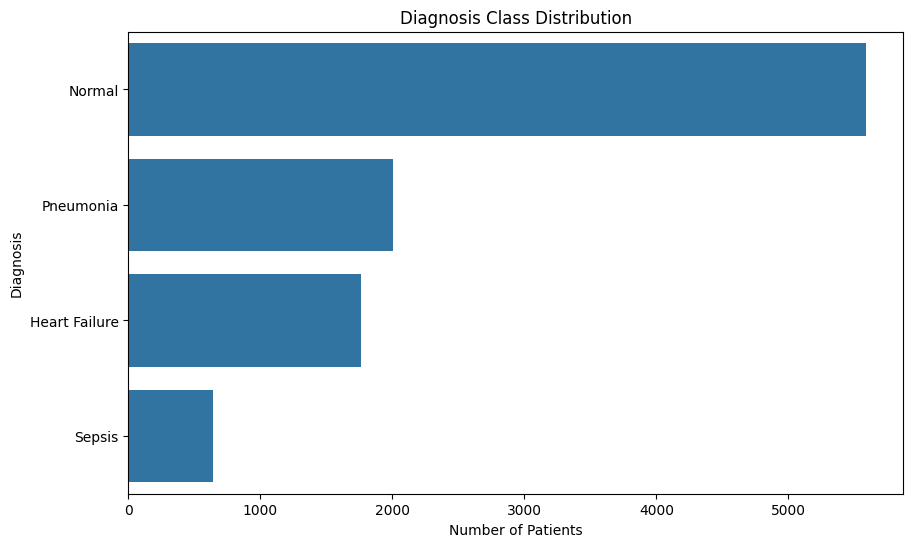

In [155]:
print(dataset['diagnosis'].value_counts())
plt.figure(figsize=(10,6))
sns.countplot(y='diagnosis', data=dataset, order=dataset['diagnosis'].value_counts().index)
plt.title("Diagnosis Class Distribution")
plt.xlabel("Number of Patients")
plt.ylabel("Diagnosis")
plt.show()

In [156]:
print("missing data:\n", dataset.isnull().sum())

missing data:
 patient_id         0
age                0
sex                0
bmi                0
systolic_bp        0
diastolic_bp       0
glucose            0
cholesterol        0
creatinine         0
diabetes           0
hypertension       0
diagnosis          0
readmission_30d    0
mortality          0
dtype: int64


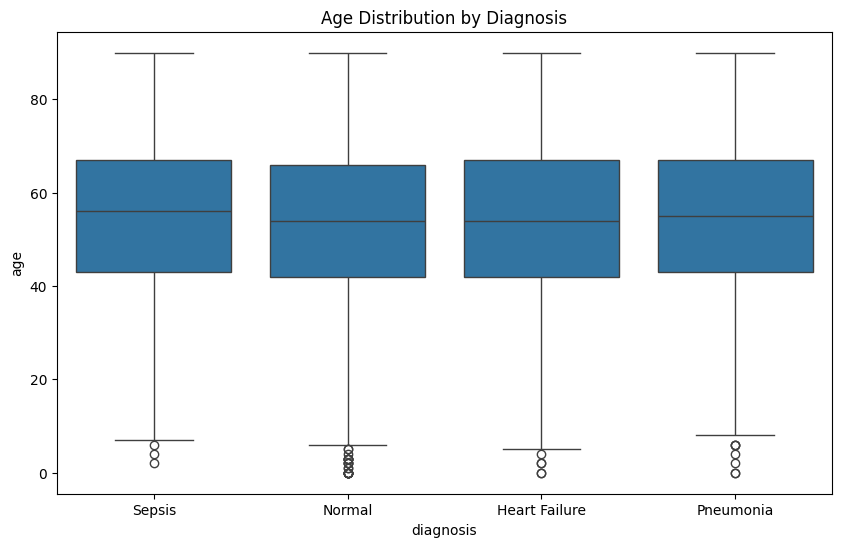

In [157]:
plt.figure(figsize=(10,6))
sns.boxplot(x='diagnosis', y='age', data=dataset)
plt.title("Age Distribution by Diagnosis")
plt.show()

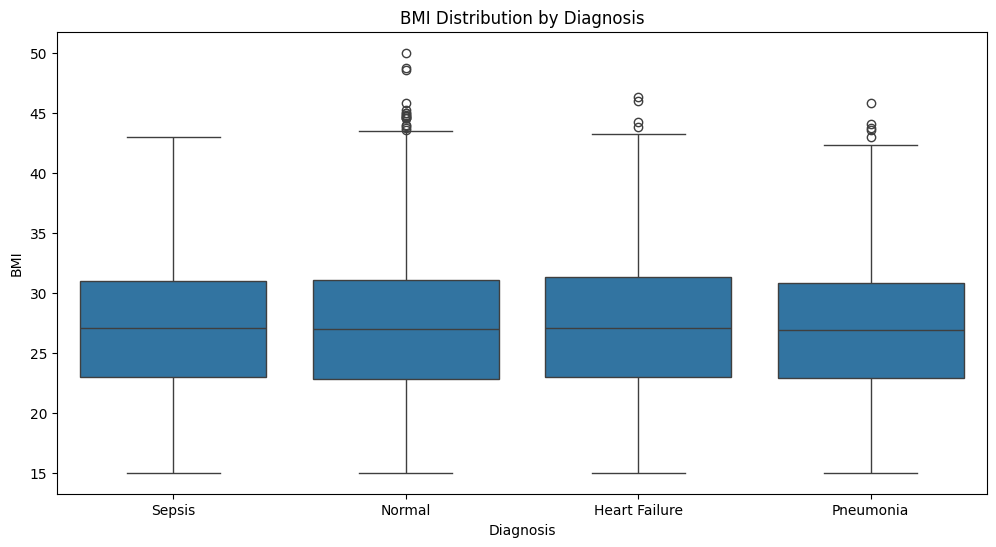

In [158]:
plt.figure(figsize=(12,6))
sns.boxplot(x='diagnosis', y='bmi', data=dataset)
plt.title("BMI Distribution by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("BMI")
plt.show()

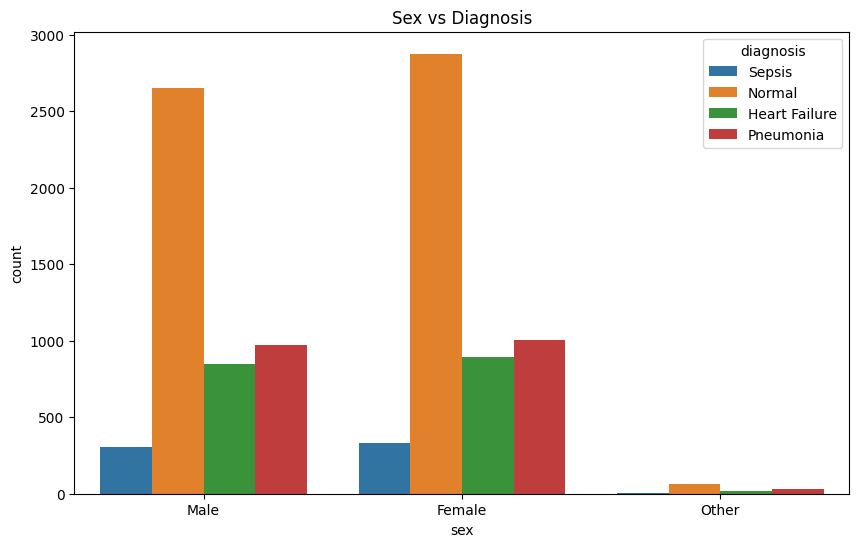

In [159]:
plt.figure(figsize=(10,6))
sns.countplot(x='sex', hue='diagnosis', data=dataset)
plt.title("Sex vs Diagnosis")
plt.show()

Summary: In a Markdown cell, write 2-3 sentences summarizing key data characteristics that will inform your modeling approach (class imbalance, missing data patterns, feature relationships you observed)
The dataset consists of alot of normal diagnosis between men and women, but intrestingly, ahs similar numbhers to pneuomia and heart failure. The full dataset does not consist of any missing values, so no cleaning or data filling will be needed in this project. Age distribution seems to be consistent across all diagnosis, not signaling a specific age gorup happens to get a certain diagnosis over the other. Finally, BMI for normal diagnosis seems to have a lot mroe outliers of 50 + compared to the other dianogisies in this dataset.

### 3. 5 Feature Categories

#### 1. Age Groups
- Calculation: I will make age into certain categories based off the age range
    - Child (0-17)
    - Young Adult (18-35)
    - Adult (36-55)
    - Senior (56-75)
    - Elderly (76+)
- Why is should help?: This would allow to further classify our data into categories and distinguish a specific age population is more likely to get a certain disaese than others. It would help create patterns for the disgnosis patterns.
- Domain Justifiucation: Age ranges are a common practical use in medical databases/studies that often suggest when people should get medication, treated, and tested. This would help to align those causes.


In [160]:
age_edge_cases = [0, 17, 35, 55, 75, 120]  
age_labels = ['Child', 'Young Adult', 'Adult', 'Senior', 'Elderly']
dataset['agegroup'] = pd.cut(dataset['age'], bins=age_edge_cases, labels=age_labels)

#### 2. BMI Category
- Calculation: I will split off BMI into to the following catoegories
    - Underweight (< 18.5)
    - Normal (18.5-24.9)
    - Overweight (25-29.9)
    - obese (30+)
- Why it should help?: THis would help capture certain BMI ranges that could lead to certain diagnosis. With the same reasoning of Age groups, BMI ranges are often used in praticiaal settings and help show patterns of when certain diagnosis can happen if a person is in a certain BMI range
- Domain Jusitifation: are a common practical use in medical databases/studies that often suggest when people should get medication, treated, and tested. This would help to align those causes.

In [161]:
bmi_edge_cases = [0, 18.5, 24.9, 29.9, 100] 
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
dataset['bmicategory'] = pd.cut(dataset['bmi'], bins=bmi_edge_cases, labels=bmi_labels)

#### 3. Blood Pressure Category
- Calculation: I will split off Blood Pressure into to the following catoegories
    - Normal (<120)
    - Elevated (120-129)
    - Hypertension Stage 1 (130-139)
    - Hypertension Stage 2 (>=140)
- Why it should help?: This would help capture certain Blood pressure ranges that could lead to certain diagnosis. With the same reasoning of Age groups and BMI, Blood pressure ranges are often used in praticiaal settings and help show patterns of when certain diagnosis can happen if a person is in a certain blood pressure status.
- Domain Jusitifation: Blood pressure measurements are a common practical use in medical databases/studies that often suggest when people should get medication, treated, and tested. This would help to align those causes.

In [162]:
bp_edge_cases = [0, 120, 130, 140, 300]
bp_labels = ['Normal', 'Elevated', 'Hypertension Stage 1', 'Hypertension Stage 2']

dataset['bp_category'] = pd.cut(dataset['systolic_bp'], bins=bp_edge_cases, labels=bp_labels)

#### 4. Gluclose Category
- Calculation: I will split off Blood Pressure into to the following catoegories
    - Normal (<100)
    - Elevated (100-125)
    - Diabetes (>=126)
- Why it should help?: This would help capture certain Gluclose levels that could lead to certain diagnosis. With the same reasoning of of previous categories, Gluclose levels are often used in praticiaal settings and help show patterns of when certain diagnosis can happen if a person has a certain gluclose level.
- Domain Jusitifation: Gluclose levels measurements are a common practical use in medical databases/studies that often suggest when people should get medication, treated, and tested. This would help to align those causes.

In [163]:
glucose_edge_cases = [0, 100, 125, 1000]
glucose_labels = ['Normal', 'Prediabetes', 'Diabetes']

dataset['glucose_category'] = pd.cut(dataset['glucose'], bins=glucose_edge_cases, labels=glucose_labels)

#### 5. Cholestrol Category
- Calculation: I will split off Blood Pressure into to the following catoegories
    - Normal (<200)
    - Borderline (200-239)
    - High (>=240)
- Why it should help?: This would help capture certain cholestrol levels that could lead to certain diagnosis. With the same reasoning of of previous categories, cholestrol levels are often used in praticiaal settings and help show patterns of when certain diagnosis can happen if a person has a certain chorelestrol level.
- Domain Jusitifation: chorelstrol levels measurements are a common practical use in medical databases/studies that often suggest when people should get medication, treated, and tested. This would help to align those causes.

In [164]:
chol_edge_cases = [0, 200, 240, 1000]
chol_labels = ['Normal', 'Borderline', 'High']

dataset['cholesterol_category'] = pd.cut(dataset['cholesterol'], bins=chol_edge_cases, labels=chol_labels)

In [165]:
print(dataset[['age', 'agegroup', 'bmi', 'bmicategory', 'systolic_bp','bp_category', 'glucose', 'glucose_category', 'cholesterol', 'cholesterol_category']].head(10))

   age agegroup   bmi  bmicategory  systolic_bp           bp_category  \
0   63   Senior  24.1       Normal        131.0  Hypertension Stage 1   
1   52    Adult  20.8       Normal        118.0                Normal   
2   66   Senior  30.0        Obese        144.0  Hypertension Stage 2   
3   82  Elderly  16.8  Underweight        112.0                Normal   
4   50    Adult  25.4   Overweight        102.0                Normal   
5   50    Adult  15.0  Underweight        140.0  Hypertension Stage 1   
6   83  Elderly  19.0       Normal        118.0                Normal   
7   68   Senior  21.7       Normal        119.0                Normal   
8   46    Adult  33.6        Obese        114.0                Normal   
9   64   Senior  31.1        Obese        116.0                Normal   

   glucose glucose_category  cholesterol cholesterol_category  
0    136.2         Diabetes        210.3           Borderline  
1    136.5         Diabetes        207.9           Borderline  
2   

### 4. Prepare Data for modeling

In [166]:
X = dataset.drop(columns=['diagnosis'])
y = dataset['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features = ['age', 'bmi']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

X_train_scaled.head()

,patient_id,age,sex,bmi,systolic_bp,diastolic_bp,glucose,cholesterol,creatinine,diabetes,hypertension,readmission_30d,mortality,agegroup,bmicategory,bp_category,glucose_category,cholesterol_category
7310,8311,-0.471702,Male,-0.014348,144.0,95.0,138.6,186.7,0.99,0,0,0,0,Adult,Overweight,Hypertension Stage 2,Diabetes,Normal
7683,8684,1.573526,Male,-0.031529,118.0,89.0,100.0,134.5,0.97,0,0,0,0,Elderly,Overweight,Normal,Normal,Normal
648,1649,-0.244454,Male,1.480401,122.0,90.0,98.2,156.1,0.50,0,0,1,0,Adult,Obese,Elevated,Normal,Normal
1986,2987,0.778160,Male,0.638531,118.0,62.0,108.8,169.4,1.05,0,1,0,0,Senior,Obese,Normal,Prediabetes,Normal
5525,6526,-0.642138,Male,-0.117434,138.0,88.0,70.0,209.8,1.41,0,0,0,0,Adult,Overweight,Hypertension Stage 1,Normal,Borderline


#### Doumentation for step4: 
- Train/Test Splits
    - 80% Training, 20% Testing (normal range we used in class for data spliting)
    - Startified by Diagnosis feature as this the feature I want to make predictions and test on with proper proportions that this dataset presented in both sets.
- Missing Values
    - There were none to fix
- Feature Scaling
    - Age and BMI were scaled using the StandardScaler method as they were numeric features that can get large and influence model training. Standarizing and scaling them would allow for mor eproper data training and data handling with my models.

### 5. Implement first model (Random Forest)

In [167]:
X_train_numeric = pd.get_dummies(X_train_scaled, columns=['agegroup', 'bmicategory', 'sex', 'bp_category', 'glucose_category', 'cholesterol_category'], drop_first=True)
X_test_numeric = pd.get_dummies(X_test_scaled, columns=['agegroup', 'bmicategory', 'sex', 'bp_category', 'glucose_category', 'cholesterol_category'], drop_first=True)

X_test_numeric_groups = X_test_numeric.reindex(columns=X_train_numeric.columns, fill_value=0)

In [168]:
random_forest_model = RandomForestClassifier(
    n_estimators=800,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

start_time = time.time()

random_forest_model.fit(X_train_numeric, y_train)

random_forest_time = time.time() - start_time

y_pred_rf = random_forest_model.predict(X_test_numeric)

balanced_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)

macro_recall_rf = recall_score(y_test, y_pred_rf, average='macro')

accuracy = accuracy_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf, average='weighted')
print("F1-score: ", f1)
print("time:", random_forest_time)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("Balanced accuarcy (sensitivity and specifitivity centered):", balanced_acc_rf)

F1-score:  0.3768148120424054
time: 1.424072504043579

Classification Report:

               precision    recall  f1-score   support

Heart Failure       0.17      0.16      0.17       353
       Normal       0.56      0.50      0.53      1118
    Pneumonia       0.20      0.25      0.22       401
       Sepsis       0.10      0.13      0.11       128

     accuracy                           0.37      2000
    macro avg       0.26      0.26      0.26      2000
 weighted avg       0.39      0.37      0.38      2000

Balanced accuarcy (sensitivity and specifitivity centered): 0.2611017756909231


Specitivity: 0.7500187090841901


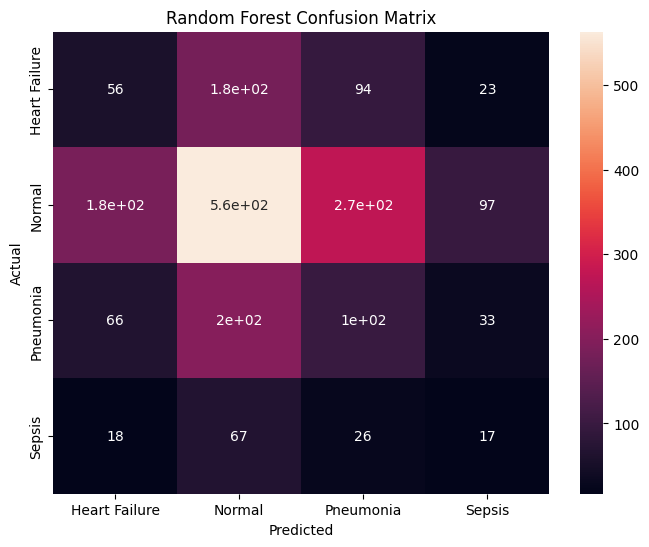

In [169]:
cm = confusion_matrix(y_test, y_pred_rf, labels=random_forest_model.classes_)

specificities = []

for i in range(len(cm)):
    TP = cm[i, i]
    
    FN = cm[i, :].sum() - TP      
    FP = cm[:, i].sum() - TP

    TN = cm.sum() - (TP + FN + FP)  
    
    specificity = TN / (TN + FP)
    specificities.append(specificity)

print("Specitivity:", np.mean(specificities))

true_negatives_rf = np.mean(specificities)



plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, xticklabels=random_forest_model.classes_, yticklabels=random_forest_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

Optimization Strategy: I made changes to my hyperparameters, with how each category are weighted, target more on sub categories with the imbalance of my data being normal, the max depth of tree, and the splits being 5. These all improved the model from the confusion matrix point of view as more categories are getting selected as perdictions as opposed to just normal as before.

### 6. Implement second model (Logistic Regression)

In [170]:
scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(X_train_numeric)
X_test_numeric = scaler.transform(X_test_numeric)

start_time = time.time()
log_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    C=.2,
)

log_model.fit(X_train_numeric, y_train)

log_time = time.time() - start_time

y_pred = log_model.predict(X_test_numeric)

f1_log = f1_score(y_test, y_pred, average='weighted')
balanced_acc_log = balanced_accuracy_score(y_test, y_pred)
macro_recall_log = recall_score(y_test, y_pred, average='macro')

print("F1-score:", f1_log)
print("Balanced Accuracy:", balanced_acc_log)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

F1-score: 0.27308917223031315
Balanced Accuracy: 0.25540553570812596

Classification Report:

               precision    recall  f1-score   support

Heart Failure       0.17      0.22      0.19       353
       Normal       0.53      0.25      0.34      1118
    Pneumonia       0.21      0.22      0.22       401
       Sepsis       0.07      0.34      0.12       128

     accuracy                           0.24      2000
    macro avg       0.25      0.26      0.22      2000
 weighted avg       0.37      0.24      0.27      2000



Specitivity: 0.7465439750025915


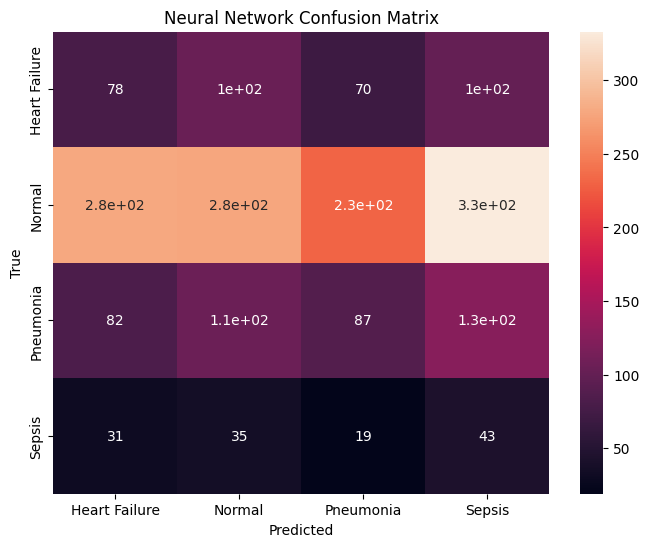

In [171]:
cm = confusion_matrix(y_test, y_pred)


specificities = []

for i in range(len(cm)):
    TP = cm[i, i]
    
    FN = cm[i, :].sum() - TP      
    FP = cm[:, i].sum() - TP

    TN = cm.sum() - (TP + FN + FP)  
    
    specificity = TN / (TN + FP)
    specificities.append(specificity)

print("Specitivity:", np.mean(specificities))

true_negatives_log = np.mean(specificities)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, xticklabels=log_model.classes_, yticklabels=log_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Neural Network Confusion Matrix')
plt.show()

Optimization Strategy: I made changes to my hyperparameters, with how strong the model is with the parmaeter C and class weight being balanced so the other categories have more weight in the training. Beng this is a new model, there was no base to improve form, but with how the confusion matrix looks, it shows that more than just normal is being hit as opposed to just having normal perdicitons with my Neural Network approach.

### 7. Comparing Models

In [172]:

random_forest_metrics = {
    "Model": "Random Forest",
    "Key Hyperparameters": "n_estimators=300, max_depth=8, min_samples_leaf=5, balanced_subsample",
    "Balanced Accuracy": balanced_acc_rf,
    "Recall": macro_recall_rf,
    "F1-score": f1,
    "True Negative": true_negatives_rf,
    "Training Time (s)": random_forest_time,
}

logistic_metrics = {
    "Model": "Logistic Regression",
    "Key Hyperparameters": "C=0.2, class_weight=balanced",
    "Balanced Accuracy": balanced_acc_log,
    "Recall": macro_recall_log,
    "F1-score": f1_log,
    "True Negative": true_negatives_log,
    "Training Time (s)": log_time,
}

comparison_df = pd.DataFrame([
    random_forest_metrics,
    logistic_metrics
])


comparison_df

,Model,Key Hyperparameters,Balanced Accuracy,Recall,F1-score,True Negative,Training Time (s)
0,Random Forest,"n_estimators=300, max_depth=8, min_samples_lea...",0.261102,0.261102,0.376815,0.750019,1.424073
1,Logistic Regression,"C=0.2, class_weight=balanced",0.255406,0.255406,0.273089,0.746544,0.027519


The modlels both were close in performance metrics for both F1 score and accuarcy. Neural Networks did slightly better by .2% in accuarcy, while random forest did better by .014 in f1 score. It is safe to say the models both performed simiarly across this dataset. I would lean more into Neural networks as it has the higher accuarcy. I feel it would be easier to improve the model with neural networks by adjsuting the amount of layers, and size of layers for the dataset.

UPDATE: I removed accuarcy as per feedback and added true negative rate, recall and balanced accuarcy to more reflect what healthcare workers would care about and for an overly imbalanced data set of normal patients.

### 8. Reflection